# Lager Language Models Reproducible submission notebook
*Team Members: Joshua Beckley, Neil Human, Christiaan Portwig*

It is important to note that some modules programmed for this hackathon isn't reproducible due to
them needing API keys. To solve this, scraped data is stored on Google Drive and downloaded from
there.

Please see the notes in the cells below for more clarification.

## Notes

- We calculate and estimate total banking activity, not banking revenue. See our presentation
for more info on this.

## Imports and Environment Setup

**Notebook makes the assumption that the notebook is being run from an environment with 
requiremnents.txt installed. It also assumes that the entire codebase was cloned.**

In [1]:
import pandas as pd
import sys
from pathlib import Path
import gdown

# This allows us to import modules from our backend
# Locate the repository even if Jupyter was launched from a different folder.
current_dir = Path.cwd().resolve()
repo_root = next(
    (path for path in (current_dir, *current_dir.parents) if (path / "backend").is_dir()),
    None,
)
if repo_root is None:
    raise RuntimeError("Could not locate the repository root containing backend/")

for import_root in (repo_root, repo_root / "backend"):
    import_root = str(import_root)
    if import_root not in sys.path:
        sys.path.insert(0, import_root)

In [2]:
def download_drive_file(link):
    path = gdown.download(url=link, output="data/")
    return Path(path)

def download_drive_folder(link: str, output_dir: str = "data/folder_downloads/"):
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    paths = gdown.download_folder(
        url=link,
        output=str(output_path),
        quiet=False,
        use_cookies=False,
    )

    return [Path(path) for path in paths]

## Processing Syn Bank data to calculate Syn bank wallet amount

In [3]:
from backend.scripts.data_aggregation import (find_cross_ledger_overlaps, build_client_wallet_baseline)

In [4]:
#Download data from drive and store as dataframe
cross_border_path = download_drive_file("https://drive.google.com/file/d/1gIDsSCO14BUrJiXLJqW8ctAi2WgCN20W/view?usp=sharing")
transactional_path = download_drive_file("https://drive.google.com/file/d/1q58Msfn8WfflYJCUzxdcfg5njDj8n2sp/view?usp=sharing")
trade_path = download_drive_file("https://drive.google.com/file/d/1DwM_OSbRqBm4aQ4ywqdOq2oqhyPPKQbj/view?usp=sharing")


cross_border_payments = pd.read_csv(cross_border_path)
transactional_banking = pd.read_csv(transactional_path)
trade_finance = pd.read_csv(trade_path)

Downloading...
From: https://drive.google.com/uc?id=1gIDsSCO14BUrJiXLJqW8ctAi2WgCN20W
To: /home/chris/dummy/LagerLanguageModelsDataschool/submission_code/data/cross_border_payments.csv
100%|██████████| 33.0M/33.0M [00:03<00:00, 9.30MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1q58Msfn8WfflYJCUzxdcfg5njDj8n2sp
From (redirected): https://drive.google.com/uc?id=1q58Msfn8WfflYJCUzxdcfg5njDj8n2sp&confirm=t&uuid=d551226d-3cd3-494c-9aef-cec1ce2d530f
To: /home/chris/dummy/LagerLanguageModelsDataschool/submission_code/data/transactional_banking.csv
100%|██████████| 393M/393M [00:38<00:00, 10.1MB/s] 
Downloading...
From: https://drive.google.com/uc?id=1DwM_OSbRqBm4aQ4ywqdOq2oqhyPPKQbj
To: /home/chris/dummy/LagerLanguageModelsDataschool/submission_code/data/trade_finance.csv
100%|██████████| 3.25M/3.25M [00:02<00:00, 1.43MB/s]


In [5]:
overlap_df = find_cross_ledger_overlaps(
    cross_border_df=cross_border_payments, 
    transactional_df=transactional_banking,
    day_tolerance=3,
    amount_tolerance_pct=1.0
)
    
final_client_table = build_client_wallet_baseline(
    transactional_df=transactional_banking,
    cross_border_df=cross_border_payments,
    trade_finance_df=trade_finance,
    overlap_df=overlap_df
)

### Results explanation

- The first part of the challenge was to figure out how much of the total banking activity 
syn bank captures for each pillar.
- There are some transactions that overlap between cross border and transactional datasets, we only
count these as one transaction. This is what is stored in overlap_df
- final_client_table then stores the calculated banking activity for each pillar.

See both these dataframes printed below.

In [6]:
overlap_df.head(2)

,transaction_id_cb,entity_id,date_cb,value_zar,direction,join_date,transaction_id_tb,date_tb,amount_zar,amount_diff_pct,day_diff
312682,XBP79767734,E08,2024-02-16,135308.55,outbound,2024-02-16,TXN23211068,2024-02-16,135308.54,0.000007,0
374378,XBP78994860,E11,2026-01-13,52796.13,inbound,2026-01-13,TXN99570229,2026-01-13,52796.14,0.000019,0


In [7]:
final_client_table.head(2)

,entity_id,entity_name,sector,txn_banking_total_zar,cross_border_total_zar,cross_border_outbound_total_zar,trade_finance_total_zar,import_trade_finance_total_zar,lending_signal_total_zar,lending_signal_txn_count,syn_bank_observed_total_zar
10,E11,Pepkor Holdings,consumer,4.789290e+10,4.880908e+09,2.731000e+09,4.539648e+09,2.387052e+09,0.0,0.0,5.731346e+10
0,E01,BHP Group,mining,3.175649e+10,2.267513e+09,1.384821e+09,3.949315e+09,2.010029e+09,0.0,0.0,3.797331e+10


## Scraping and Processing external data

This is one of the biggest challenges - collecting external data and processing it.

### Scraping external data

External data scraping happens in data_collection.py. 

Scraping takes part in 2 parts:
- Scraping annual reports, financial statements, interim results and results presentations:
    - We have a list of hardcoded URLs for where the module should attempt to scrape the data from. We 
    then use keyword searching with bs4 to scrape the documents listed as some of these keywords from
    the webpages. We also use Crawl4ai as a backup scraper, this sometimes performs better if javascript 
    needs to load the documents.
    - Find out more about this in our presentation, but we scrape this daily in our pipeline.
    - **GenAI** is used to ensure that the processed documents are correct
- Scraping SENS data:
    - SENS data is easier to access and is scraped directly from the JSEs webpage.
    - We have a "smart scraping" algorithm that only attempts to scrape announcements newer than
    the newest one we've scraped

In [9]:
from backend.scripts.data_collection import DataCollector

In [ ]:
# NOTE: We validate that the correct document names were scraped by using Gemini, so these methods
# can't be rerun on judges machines(without a gemini api key) scraped data is about 1GB on my 
# machine, so downloading will take too long. I have a modified version with some documents 
# delected that will be downloaded here so you can see the download structure

# NOTE: Uncomment to run the scrape
# Scrape annual reports, financial statements, interim results and results presentations
my_collector = DataCollector()

# This collects all data, scope can also just be "sens".
# Note that this also validates
# my_collector.collect_data(scrape_scope="all")

In [ ]:
# This dowloads the partial scraped data mentioned above. Note that the scraper actually creates
# a folder for every company
download_drive_folder("https://drive.google.com/drive/folders/1JK1DP8VtYlPOuSrk_0js5dSSqGklfiMn?usp=sharing")

Retrieving folder contents


Retrieving folder 1exqd0FjzlEEiROUBcaBO2IfSIX2Ck2am Prosus
Retrieving folder 1eURrwtzWwLrt_VBlneTKc1waU3sxYG7k SENS
Processing file 1Z9VS6xqhXcnBUnRTorvspYGlmlRDpyGh 2026-07-28__S524723__Update_on_Repurchase_Programme.pdf
Processing file 1VYlGRSdsBb_-oAbGf4SlSbMOB3eGTBt4 2026-08-04__S525088__Update_on_Repurchase_Programme.pdf
Processing file 139bb-FgWVjeeQ9KkgeGgWJO0a1U6xttD announcements.json
Processing file 1hTRd7CMhE3g2tkFftaWKcqK4EhYYP7Vo annual_report__2026__fy2026-annual-report.pdf
Processing file 1jz5t9iEUsAJs1nSngrGpXiKwb1Szp1u8 financial_statements__2026__fy2026-annual-report.pdf
Retrieving folder 1IAQgktdiVmYkw2CgHcfXEKFzsirq8fEo Vodacom_Group
Retrieving folder 1EEvx3tpa-ZDoS5rUdfAczF2IjqTLfShH SENS
Processing file 1f9TA5bTD1iD0t5OTwnKDDMUXMtZCFr3t 2026-06-15__S522777__Allocation_of_conditional_and_forfeitable_shares.pdf
Processing file 12dH6DD3BNLUAQRGacnMycodkG1zvv_gx 2026-06-25__S523188__Vesting_of_conditional_and_forfeitable_shares.pdf
Processing file 1PomB2wuw1pSAV5rf_2G

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1Z9VS6xqhXcnBUnRTorvspYGlmlRDpyGh
To: /home/chris/LagerLanguageModelsDataschool/submission_code/data/folder_downloads/Prosus/SENS/2026-07-28__S524723__Update_on_Repurchase_Programme.pdf
100%|██████████| 226k/226k [00:00<00:00, 373kB/s]
Downloading...
From: https://drive.google.com/uc?id=1VYlGRSdsBb_-oAbGf4SlSbMOB3eGTBt4
To: /home/chris/LagerLanguageModelsDataschool/submission_code/data/folder_downloads/Prosus/SENS/2026-08-04__S525088__Update_on_Repurchase_Programme.pdf
100%|██████████| 226k/226k [00:00<00:00, 327kB/s]
Downloading...
From: https://drive.google.com/uc?id=139bb-FgWVjeeQ9KkgeGgWJO0a1U6xttD
To: /home/chris/LagerLanguageModelsDataschool/submission_code/data/folder_downloads/Prosus/SENS/announcements.json
100%|██████████| 87.2k/87.2k [00:00<00:00, 233kB/s]
Downloading...
From: https://drive.google.com/uc?id=1hTRd7CMhE3g2t

[PosixPath('data/folder_downloads/Prosus/SENS/2026-07-28__S524723__Update_on_Repurchase_Programme.pdf'),
 PosixPath('data/folder_downloads/Prosus/SENS/2026-08-04__S525088__Update_on_Repurchase_Programme.pdf'),
 PosixPath('data/folder_downloads/Prosus/SENS/announcements.json'),
 PosixPath('data/folder_downloads/Prosus/annual_report__2026__fy2026-annual-report.pdf'),
 PosixPath('data/folder_downloads/Prosus/financial_statements__2026__fy2026-annual-report.pdf'),
 PosixPath('data/folder_downloads/Vodacom_Group/SENS/2026-06-15__S522777__Allocation_of_conditional_and_forfeitable_shares.pdf'),
 PosixPath('data/folder_downloads/Vodacom_Group/SENS/2026-06-25__S523188__Vesting_of_conditional_and_forfeitable_shares.pdf'),
 PosixPath('data/folder_downloads/Vodacom_Group/SENS/2026-06-26__S523316__Vesting_of_forfeitable_shares.pdf'),
 PosixPath('data/folder_downloads/Vodacom_Group/SENS/2026-06-26__S523319__Sale_of_vested_conditional_and_forfeitable_shares.pdf'),
 PosixPath('data/folder_downloads/Vo

### Processing external data

We use mainly Gemini to process the scraped external data. This is where things get unreproducible, 
since the judges don't have our Gemini key. We download processed data from google drive for 
reproducibility.

The processing part consists of multiple parts:

- The initial scraping of documents. Both SENS and other documents are scraped using Gemini and the 
results are stored in saved csv documents.
- The standardizing of scraped data. This converts all values to ZAR.
- The validation of data. We use a module that scrapes yahoo finance to validate all fields that 
can be validated. In practice, a paid API should be use to adhere to terms and conditions

**Note: The further processing of SENS data will be discussed later**

In [ ]:
from backend.scripts.data_processing import Data_Processor

my_processor = Data_Processor()

In [ ]:

# Processing data using gemini
# Note that we only process unprocesses data.
# Make sure only unprocessed gets processed:
#my_processor.prepare_incremental_data()
#Now, only process new data, note default argument values
#my_processor.process_new_data()

In [ ]:
#The processed data will look something like this

In [ ]:
sens_scraped_loc = download_drive_file("https://drive.google.com/file/d/1R9cvz8GOJG4_nkFbzOhENnH2G0bRxgfp/view?usp=sharing")
external_scraped_loc = download_drive_file("https://drive.google.com/file/d/1ulP6BYARkzUg5PsHp0pkByQmIWNGRU5O/view?usp=sharing")

sens_scraped_df = pd.read_csv(sens_scraped_loc)
external_scraped_df = pd.read_csv(external_scraped_loc)

Downloading...
From: https://drive.google.com/uc?id=1R9cvz8GOJG4_nkFbzOhENnH2G0bRxgfp
To: /home/chris/LagerLanguageModelsDataschool/submission_code/data/sens_scraped_from_pdf.csv
100%|██████████| 58.3k/58.3k [00:00<00:00, 203kB/s]
Downloading...
From: https://drive.google.com/uc?id=1ulP6BYARkzUg5PsHp0pkByQmIWNGRU5O
To: /home/chris/LagerLanguageModelsDataschool/submission_code/data/company_lvl_scraped_from_pdf.csv
100%|██████████| 47.7k/47.7k [00:00<00:00, 163kB/s]


In [ ]:
sens_scraped_df.head(2)

,Unnamed: 0,company,announcement_date,title,source_document,source_url,event_type,event_value,event_unit,currency,counterparty,target_or_asset,country,expected_completion_date,banking_opportunities,opportunity_summary,extra_notes
0,0,Anglo American,2025-01-29,Anglo American completes sale of minority inte...,Anglo American completes sale of minority inte...,NaN,disposal,1.600000e+09,units,AUD,Zashvin Pty Ltd,33% minority interest in Jellinbah Group Pty Ltd,AU,NaN,"['fx', 'liquidity_management', 'payments']",Inflows from the disposal of Jellinbah stake c...,Completed the sale of a 33.3% minority interes...
1,1,Anglo American,2025-02-17,Anglo American sets out June demerger timeline...,Anglo American sets out June demerger timeline...,NaN,restructuring,1.100000e+09,units,USD,NaN,Anglo American Platinum Limited,ZA,2025-06-30,"['corporate_finance', 'equity_capital_markets'...",Demerger and corporate restructuring of Anglo ...,Sets out timeline for demerger of Anglo Americ...


In [ ]:
external_scraped_df.head(2)

,Unnamed: 0,company,report_date,reporting_period_type,reporting_currency,reporting_unit,source_document,revenue,cost_of_sales,inventory,...,major_contractual_commitments,order_book_project_pipeline,assets_under_management,market_capitalisation,share_price,share_return,enterprise_value,credit_rating,ownership_major_shareholders,extra_notes
0,0,Anglo American,2025-12-31,annual,USD,units,financial_statements__2025__aa-annual-report-f...,1.854600e+10,1.719400e+10,3.819000e+09,...,Outstanding commitments relating to take or pa...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['BlackRock Inc.', 'Epoch Two Investment Holdi...",Anglo American is undergoing major portfolio t...
1,1,AngloGold Ashanti,2025-12-31,annual,USD,units,financial_statements__2025__financial_statemen...,9.893000e+09,5.022000e+09,1.251000e+09,...,Contracted capital expenditure of 378 million;...,NaN,NaN,NaN,85.28,2.75,NaN,BB+ / Baa3,"['BlackRock Inc.', 'BlackRock, Inc.', 'Public ...",AngloGold Ashanti redomiciled in late 2023 wit...


Now, we need to standardize to ZAR

In [ ]:
external_stand, sens_stand = my_processor.standardize_data(external_scraped_df, sens_scraped_df)

Finally, we validate the data against yfinance to ensure that what we scraped is correct, if there 
is a difference, we assume that the one on yahoo finance is correct. Note that this takes about a 
minute to run.

In [ ]:
external_valid, sens_valid = my_processor.validate_external_data(external_stand, sens_stand)

14:01:57 | WARNING | Anglo American: cost_of_sales differs from yfinance AGL.JO (np.float64(285170574611.6638) != 148688740339.27917); using the yfinance value
14:01:57 | WARNING | Anglo American: finance_costs differs from yfinance AGL.JO (np.float64(8160051338.195801) != 14296675312.042236); using the yfinance value
14:01:57 | WARNING | Anglo American: inventory differs from yfinance AGL.JO (np.float64(63339910692.214966) != 49972021711.34949); using the yfinance value
14:01:57 | WARNING | Anglo American: trade_payables differs from yfinance AGL.JO (np.float64(41115380624.77112) != 83839551858.90198); using the yfinance value
14:01:57 | WARNING | Anglo American: short_term_debt differs from yfinance AGL.JO (np.float64(17530842000.961304) != 13450816331.863403); using the yfinance value
14:01:57 | WARNING | Anglo American: debt_due_within_12_months differs from yfinance AGL.JO (np.float64(17530842000.961304) != 13450816331.863403); using the yfinance value
14:01:57 | WARNING | Anglo A

In [ ]:
external_valid.head(2)

,Unnamed: 0,company,report_date,reporting_period_type,reporting_currency,reporting_unit,source_document,revenue,cost_of_sales,inventory,...,market_capitalisation,share_price,share_return,enterprise_value,credit_rating,ownership_major_shareholders,extra_notes,original_currency,fx_rate_to_zar,fx_rate_date
0,0,Anglo American,2025-12-31,annual,ZAR,units,financial_statements__2025__aa-annual-report-f...,3.075941e+11,1.486887e+11,4.997202e+10,...,9.107647e+11,850.00,0.673064,9.258390e+11,NaN,"[Atlas Capital Advisors Inc, Capital Income Bu...",Anglo American is undergoing major portfolio t...,USD,16.58547,2025-12-31
1,1,AngloGold Ashanti,2025-12-31,annual,ZAR,units,financial_statements__2025__financial_statemen...,1.640801e+11,8.329223e+10,1.784597e+10,...,7.882667e+11,1558.55,0.641374,7.963488e+11,BB+ / Baa3,"[Blackrock Inc., Capital World Growth & Income...",AngloGold Ashanti redomiciled in late 2023 wit...,USD,16.58547,2025-12-31


In [ ]:
sens_valid.head(2)

,Unnamed: 0,company,announcement_date,title,source_document,source_url,event_type,event_value,event_unit,currency,counterparty,target_or_asset,country,expected_completion_date,banking_opportunities,opportunity_summary,extra_notes,original_currency,fx_rate_to_zar,fx_rate_date
0,0,Anglo American,2025-01-29,Anglo American completes sale of minority inte...,Anglo American completes sale of minority inte...,NaN,disposal,1.866096e+10,units,ZAR,Zashvin Pty Ltd,33% minority interest in Jellinbah Group Pty Ltd,AU,NaN,"['fx', 'liquidity_management', 'payments']",Inflows from the disposal of Jellinbah stake c...,Completed the sale of a 33.3% minority interes...,AUD,11.6631,2025-01-29
1,1,Anglo American,2025-02-17,Anglo American sets out June demerger timeline...,Anglo American sets out June demerger timeline...,NaN,restructuring,2.018060e+10,units,ZAR,NaN,Anglo American Platinum Limited,ZA,2025-06-30,"['corporate_finance', 'equity_capital_markets'...",Demerger and corporate restructuring of Anglo ...,Sets out timeline for demerger of Anglo Americ...,USD,18.346001,2025-02-17


## Estimating wallet size with scraped data

**A quick explanation of how this is calculated**
For every pillar, we have formulas defined for how the total wallet size is calculated. These 
formulas consist of calculated variables. Each low level calculation has a fallback formula for if 
the required fields are unavailable.

Based on availability and use of fallback methods, we return an accuracy value.

On the dashboard, the banker can manually fill in missing values

In [ ]:
from backend.scripts.wallet_size import calculate_total_wallet_size

In [ ]:
wallet_size = calculate_total_wallet_size(external_valid, sens_valid)
wallet_size.head(2)

Anglo American: transactional_banking confidence is low because trade_finance: Tier C proxy; missing trade_exposure_value, letters_of_credit_disclosed, imports_value, exports_value, trade_exposure_share
Anglo American: global_markets confidence is low because foreign_exchange: unavailable; missing fx_transaction_value, fx_derivative_notional, fx_exposure_value, foreign_revenue, imports_value, foreign_revenue_share | interest_rates: Tier C proxy; missing interest_rate_derivative_notional, floating_rate_debt | commodities: unavailable; missing commodity_derivative_notional, commodity_exposure_value
Anglo American: investment_banking confidence is low because lending: Tier C proxy; missing bank_loans_and_credit_facilities, bank_loan_debt, explicit_bank_loans, non_bank_debt, identified_bonds, bond_debt | equity_capital_markets: unavailable; missing _event_ecm_value, equity_raise_value, rights_issue_value, equity_issuance_value, other_equity_issuance_value | project_finance: Tier C proxy; m

,transactional_banking,global_markets,investment_banking,total,transactional_banking_confidence,global_markets_confidence,investment_banking_confidence
company,,,,,,,
Anglo American,7.945767e+11,2.567597e+11,5.954017e+11,1.646738e+12,low,low,low
AngloGold Ashanti,4.222827e+11,3.331192e+11,6.845196e+10,8.238538e+11,low,low,low


### Full formula breakdown

For every product, use the **first available formula** in priority order: **Tier A → Tier B → Tier C**. A product is omitted if none of its tier formulas can be calculated.

#### Transactional banking

| Product | Tier A | Tier B | Tier C |
|---|---|---|---|
| Payments | `cost_of_sales + employee_expenses + tax_paid + dividends_paid` | `cost_of_sales + employee_expenses` | `0.5 * revenue` |
| Collections | First available: `collections_value`, `revenue` | `adjusted_collections_value` | `0.5 * revenue` |
| Liquidity management | First available: `average_cash_and_cash_equivalents`, `average_cash_balance` | `cash_and_cash_equivalents` | `current_cash_balance` |
| Trade finance | First available: `trade_exposure_value`, `letters_of_credit_disclosed`; otherwise `imports_value + exports_value` | `cost_of_sales * trade_exposure_share` | `cost_of_sales` |
| Guarantees | `guarantees_outstanding` | First available: `guarantee_project_obligations`, `contingent_liabilities` | — |

$$TransactionalBanking = Payments + Collections + LiquidityManagement + TradeFinance + Guarantees$$

#### Global markets

| Product | Tier A | Tier B | Tier C |
|---|---|---|---|
| Foreign exchange | First available: `fx_transaction_value`, `fx_derivative_notional`, `fx_exposure_value` | `foreign_revenue + imports_value` | `foreign_revenue`; otherwise `revenue * foreign_revenue_share` |
| Interest rates | `interest_rate_derivative_notional` | `floating_rate_debt` | `total_debt` |
| Commodities | `commodity_derivative_notional` | `commodity_exposure_value` | `revenue * commodity_exposure_share`; otherwise `commodity_linked_revenue` |

$$GlobalMarkets = ForeignExchange + InterestRates + Commodities$$

#### Investment banking

| Product | Tier A | Tier B | Tier C |
|---|---|---|---|
| Lending | First available: `bank_loans_and_credit_facilities`, `bank_loan_debt`, `explicit_bank_loans` | $\max(0, total\_debt - non\_bank\_debt)$, where the deduction is the first available of `non_bank_debt`, `identified_bonds`, `bond_debt` | `total_debt` |
| Debt capital markets | First available: event DCM value, `bond_issue_value` | `upcoming_bond_maturities_value` | — |
| Equity capital markets | First available: event ECM value, `equity_raise_value`, `rights_issue_value` | First available: `equity_issuance_value`, `other_equity_issuance_value` | — |
| Advisory | First available: event advisory value, `deal_value`; otherwise sum available `acquisition_value + disposal_value + restructuring_value` | `corporate_transaction_value` | — |
| Project finance | First available: event project-financing value, `external_project_financing`, `external_debt_raised` | First available: `project_debt`, `project_facility_value` | First available: event project value, `project_or_contract_value`, `project_value`, `capital_expenditure` |

$$InvestmentBanking = Lending + DCM + ECM + Advisory + ProjectFinance$$

#### Total wallet

$$\boxed{TotalWallet = TransactionalBanking + GlobalMarkets + InvestmentBanking}$$

Unavailable products are excluded from their pillar subtotal. A pillar is undefined only if none of its products can be estimated. `TotalWallet` is undefined unless all three pillars can be estimated. Pillar confidence is determined by its weakest included tier: **A = high, B = medium, C = low**.

## Calculating final results

Final share is then calculated and stored in json format for our webpage.

In order for us to rank the companies, we need to score them. See the end of this section for the 
full score formula

### Scoring sens announcements

We use gemini to give each pillar of each sens announcement a score from 0 to 1. Once again, this 
is downloaded from google drive 

In [ ]:
# Score announcements with Gemini
#scored_sens = my_processor.score_sens_opportunities(sens_stand)

scored_sens_loc = download_drive_file("https://drive.google.com/file/d/1dBv7hZYeLLCenLHzVzXHZJ92cAjlLlMO/view?usp=sharing")
scored_sens = pd.read_csv(scored_sens_loc)

Downloading...
From: https://drive.google.com/uc?id=1dBv7hZYeLLCenLHzVzXHZJ92cAjlLlMO
To: /home/chris/LagerLanguageModelsDataschool/submission_code/data/opportunities_sens.csv
100%|██████████| 60.0k/60.0k [00:00<00:00, 186kB/s]


In [ ]:
scored_sens.head(2)

,Unnamed: 0.1,Unnamed: 0,company,announcement_date,title,source_document,source_url,event_type,event_value,event_unit,...,counterparty,target_or_asset,country,expected_completion_date,banking_opportunities,opportunity_summary,extra_notes,transactional_banking_opportunity_score,global_markets_opportunity_score,investment_banking_opportunity_score
0,0,0,Anglo American,2025-01-29,Anglo American completes sale of minority inte...,Anglo American completes sale of minority inte...,NaN,disposal,1.600000e+09,units,...,Zashvin Pty Ltd,33% minority interest in Jellinbah Group Pty Ltd,AU,NaN,"['fx', 'liquidity_management', 'payments']",Inflows from the disposal of Jellinbah stake c...,Completed the sale of a 33.3% minority interes...,0.85,0.8,0.30
1,1,1,Anglo American,2025-02-17,Anglo American sets out June demerger timeline...,Anglo American sets out June demerger timeline...,NaN,restructuring,1.100000e+09,units,...,NaN,Anglo American Platinum Limited,ZA,2025-06-30,"['corporate_finance', 'equity_capital_markets'...",Demerger and corporate restructuring of Anglo ...,Sets out timeline for demerger of Anglo Americ...,0.20,0.4,0.95


Next, we decay older sens announcements. We use exponential decay with a half life parameter. Once 
again, this parameter can be changed in the dashboard

In [ ]:
decayed_sens = my_processor.apply_sens_score_decay(scored_sens)
decayed_sens.head(2)

,Unnamed: 0.1,Unnamed: 0,company,announcement_date,title,source_document,source_url,event_type,event_value,event_unit,...,counterparty,target_or_asset,country,expected_completion_date,banking_opportunities,opportunity_summary,extra_notes,transactional_banking_opportunity_score,global_markets_opportunity_score,investment_banking_opportunity_score
0,0,0,Anglo American,2025-01-29,Anglo American completes sale of minority inte...,Anglo American completes sale of minority inte...,NaN,disposal,1.600000e+09,units,...,Zashvin Pty Ltd,33% minority interest in Jellinbah Group Pty Ltd,AU,NaN,"['fx', 'liquidity_management', 'payments']",Inflows from the disposal of Jellinbah stake c...,Completed the sale of a 33.3% minority interes...,0.011040,0.010390,0.003896
1,1,1,Anglo American,2025-02-17,Anglo American sets out June demerger timeline...,Anglo American sets out June demerger timeline...,NaN,restructuring,1.100000e+09,units,...,NaN,Anglo American Platinum Limited,ZA,2025-06-30,"['corporate_finance', 'equity_capital_markets'...",Demerger and corporate restructuring of Anglo ...,Sets out timeline for demerger of Anglo Americ...,0.003007,0.006014,0.014283


Finally, we can now calculate the scores

In [ ]:
from backend.scripts.data_aggregation import calculate_client_score

In [ ]:
client_scores = calculate_client_score(final_client_table, decayed_sens, wallet_size)
client_scores.head(2)

,entity_id,entity_name,transactional_banking_total_wallet,transactional_banking_captured_wallet,transactional_banking_wallet_gap,transactional_banking_gap_score,transactional_banking_raw_sens,transactional_banking_sens_score,transactional_banking_current_wallet_share,transactional_banking_relationship_score,...,investment_banking_total_wallet,investment_banking_captured_wallet,investment_banking_wallet_gap,investment_banking_gap_score,investment_banking_raw_sens,investment_banking_sens_score,investment_banking_current_wallet_share,investment_banking_relationship_score,investment_banking_score,total_score
0,E11,Pepkor Holdings,2.290320e+11,5.243255e+10,1.765994e+11,0.008288,0.755056,0.075568,0.228931,1.0,...,3.678600e+10,0.0,3.678600e+10,0.009972,1.166698,0.107773,0.0,0.125,0.060595,0.121468
1,E01,BHP Group,2.035681e+12,3.570580e+10,1.999975e+12,0.093865,0.331063,0.033134,0.017540,0.6,...,2.833182e+11,0.0,2.833182e+11,0.076799,0.482095,0.044533,0.0,0.125,0.068713,0.134930


### Full client opportunity-score formula

Let $i$ identify a client, $p$ a banking pillar, $j$ all clients, $e$ a SENS announcement, and $h=90$ days the default SENS half-life.

#### Captured wallet and wallet gap

$$CapturedWallet_{i,p}=\begin{cases}TxnBankingTotal_i+TradeFinanceTotal_i & p=TransactionalBanking\\CrossBorderTotal_i & p=GlobalMarkets\\LendingSignalTotal_i & p=InvestmentBanking\end{cases}$$

$$WalletGap_{i,p}=TotalWallet_{i,p}-CapturedWallet_{i,p}$$

$$GapScore_{i,p}=\frac{WalletGap_{i,p}}{\sum_j WalletGap_{j,p}}$$

If the cohort's total gap for a pillar is zero, `GapScore` is set to zero.

#### Time-decayed SENS score

$$DecayedSENS_{i,e,p}=OriginalSENS_{i,e,p}\times2^{-AgeDays_{i,e}/h}$$

With the default half-life, $h=90$. Scores with no announcement date are not decayed.

$$RawSENS_{i,p}=\sum_e DecayedSENS_{i,e,p}$$

$$SENSScore_{i,p}=\frac{RawSENS_{i,p}}{\sum_j RawSENS_{j,p}}$$

A client with no announcements receives `RawSENS = 0`. If the cohort's total raw SENS value is zero, `SENSScore` is set to zero.

#### Relationship score

$$CurrentWalletShare_{i,p}=\frac{CapturedWallet_{i,p}}{TotalWallet_{i,p}}$$

$$RelationshipScore_{i,p}=PercentileRank_p(CurrentWalletShare_{i,p})$$

The implementation uses `rank(method="average", pct=True)`, including average ranks for ties.

#### Pillar and overall scores

$$\boxed{PillarScore_{i,p}=0.50GapScore_{i,p}+0.40SENSScore_{i,p}+0.10RelationshipScore_{i,p}}$$

The total score is the wallet-gap-weighted average of the available pillar scores:

$$\boxed{TotalScore_i=\frac{\sum_p WalletGap_{i,p}PillarScore_{i,p}}{\sum_p WalletGap_{i,p}}}$$

Fully expanded:

$$TotalScore_i=\frac{\sum_p WalletGap_{i,p}\left(0.50\frac{WalletGap_{i,p}}{\sum_j WalletGap_{j,p}}+0.40\frac{RawSENS_{i,p}}{\sum_j RawSENS_{j,p}}+0.10PercentileRank_p\left(\frac{CapturedWallet_{i,p}}{TotalWallet_{i,p}}\right)\right)}{\sum_p WalletGap_{i,p}}$$

Scores are returned on a 0-to-1 scale. For a percentage, use $DisplayedScore_i=100\times TotalScore_i$. The total score is undefined when the client's usable pillar gaps sum to zero.

## Calculating cash cycles, payment timing and best moment for client engagement

First, some EDA was done to ensure that we can calculate this:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

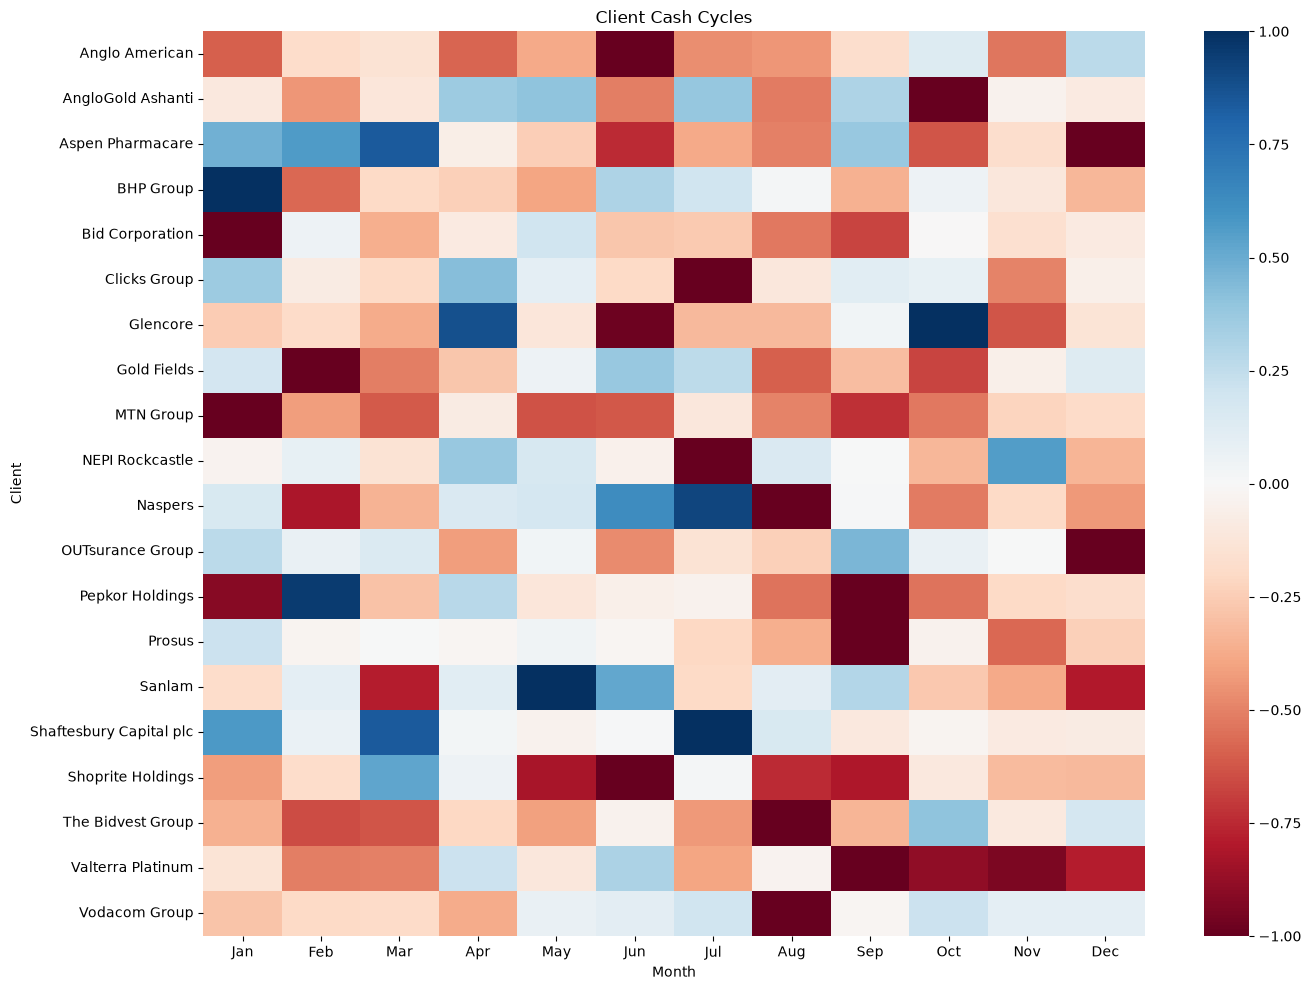

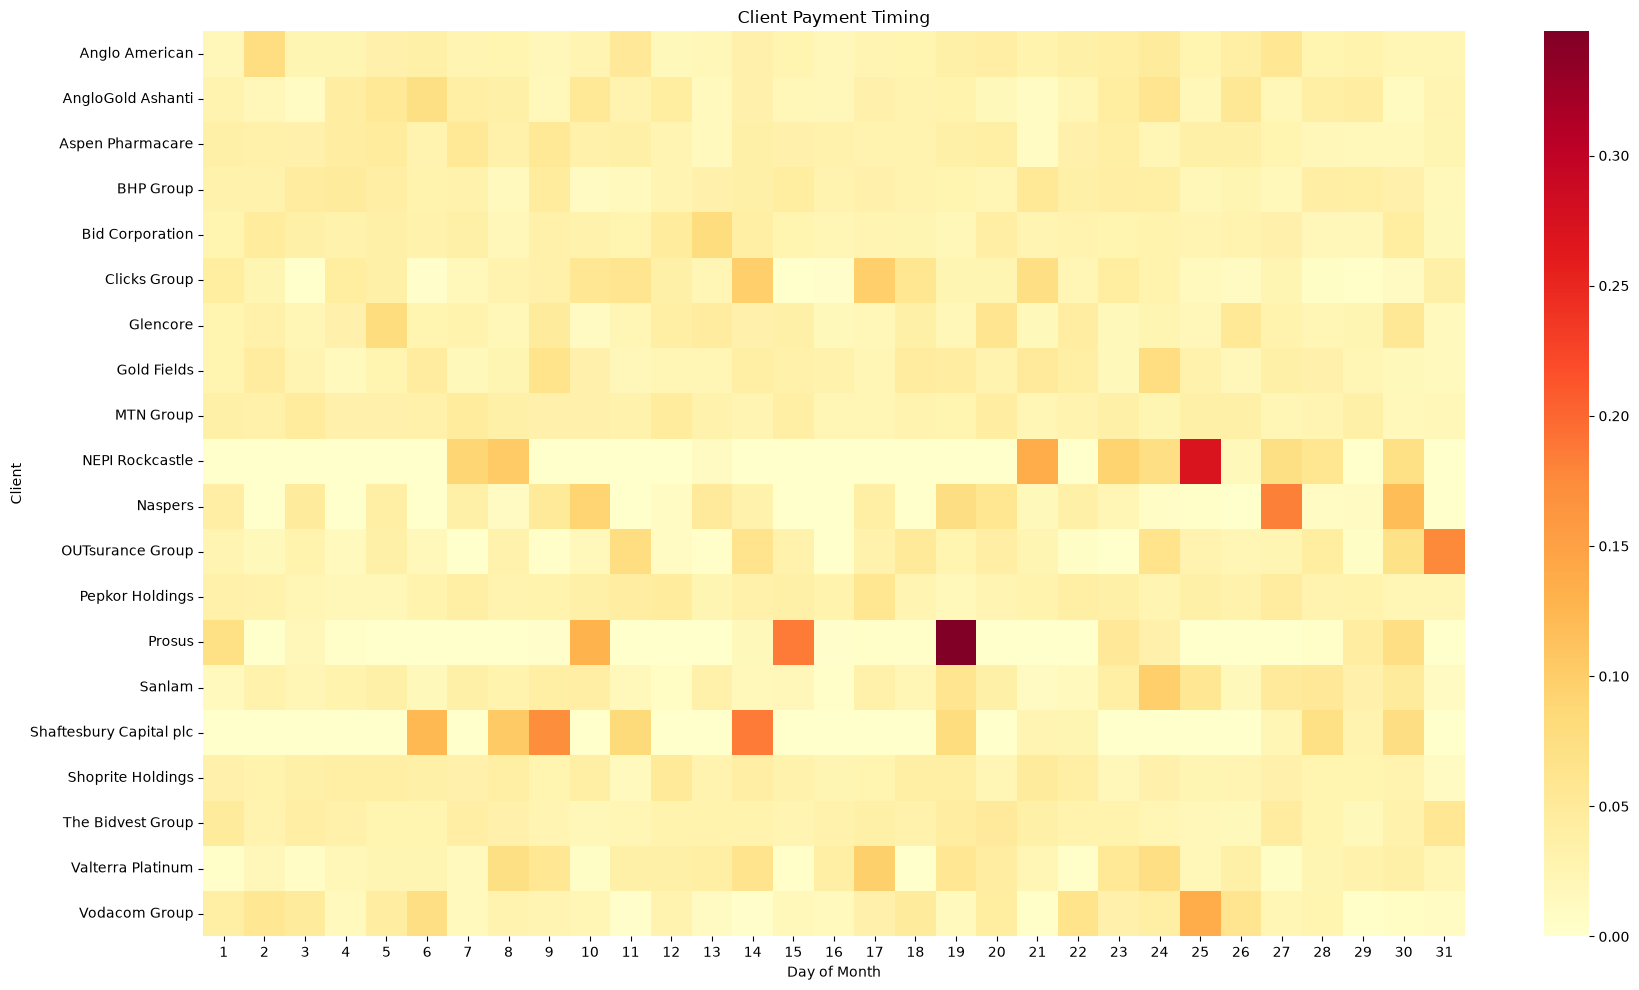

In [ ]:
tb = transactional_banking[
    ["entity_name", "date", "direction", "amount_zar"]
].rename(columns={"amount_zar": "value_zar"})

cb = cross_border_payments[
    ["entity_name", "date", "direction", "value_zar"]
]

tf = trade_finance[
    ["entity_name", "date", "direction", "value_zar"]
]

df = pd.concat([tb, cb, tf], ignore_index=True)

df["date"] = pd.to_datetime(df["date"])
df["value_zar"] = pd.to_numeric(df["value_zar"], errors="coerce")
df["direction"] = df["direction"].astype(str).str.lower().str.strip()

inflows = ["credit", "inflow", "incoming", "in", "export"]
outflows = ["debit", "outflow", "outgoing", "out", "import"]

df["signed_value"] = np.where(
    df["direction"].isin(inflows),
    df["value_zar"],
    np.where(
        df["direction"].isin(outflows),
        -df["value_zar"],
        0
    )
)

df["month"] = df["date"].dt.month

cash_cycle = (
    df.groupby(["entity_name", "month"])["signed_value"]
      .mean()
      .unstack(fill_value=0)
      .reindex(columns=range(1, 13), fill_value=0)
)

cash_cycle_norm = cash_cycle.div(
    cash_cycle.abs().max(axis=1).replace(0, 1),
    axis=0
)

plt.figure(figsize=(14, 10))

sns.heatmap(
    cash_cycle_norm,
    cmap="RdBu",
    center=0,
    xticklabels=[
        "Jan", "Feb", "Mar", "Apr", "May", "Jun",
        "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
    ]
)

plt.title("Client Cash Cycles")
plt.xlabel("Month")
plt.ylabel("Client")
plt.tight_layout()
plt.show()

payments = df[
    df["direction"].isin(outflows)
].copy()

payments["day"] = payments["date"].dt.day

payment_timing = (
    payments.groupby(["entity_name", "day"])["value_zar"]
            .sum()
            .unstack(fill_value=0)
            .reindex(columns=range(1, 32), fill_value=0)
)

payment_timing_norm = payment_timing.div(
    payment_timing.sum(axis=1).replace(0, 1),
    axis=0
)

plt.figure(figsize=(18, 10))

sns.heatmap(
    payment_timing_norm,
    cmap="YlOrRd"
)

plt.title("Client Payment Timing")
plt.xlabel("Day of Month")
plt.ylabel("Client")
plt.tight_layout()
plt.show()

### Interpretation of heatmaps

From the heatmaps, it can be seen that it is plausible to want to predict cash cycles and 
payment timing based on internal data. It will be assumed that syn bank data models the full 
population. This is a bold assumption, but the best that we can do.

From this, we process the data and send it to gemini to score:

In [ ]:
from backend.scripts.payment_cycles_timing import *

In [ ]:
# Once again, gemini is used...
#results = build_client_timing_intelligence(
#    data_dir="data",
#    reference_date="2026-08-16",
#    use_gemini=True,
#)
#pd.DataFrame(results)

In [ ]:
results_loc = download_drive_file("https://drive.google.com/file/d/1GCgz-tanp_fnmRhiqYNIr6uLNSwBGISm/view?usp=sharing")
results_df = pd.read_csv(results_loc)
results_df.head(2)

Downloading...
From: https://drive.google.com/uc?id=1GCgz-tanp_fnmRhiqYNIr6uLNSwBGISm
To: /home/chris/LagerLanguageModelsDataschool/submission_code/data/scores.csv
100%|██████████| 65.5k/65.5k [00:00<00:00, 194kB/s]


,Unnamed: 0,entity_id,entity_name,cash_cycle,payment_timing,engagement_prediction
0,0,E01,BHP Group,"{'cash_in': {'peak_day': 9, 'window_start_day'...","{'peak_day': 21, 'window_start_day': 18, 'wind...","{'recommended_engagement_date': '2026-08-16', ..."
1,1,E02,Glencore,"{'cash_in': {'peak_day': 18, 'window_start_day...","{'peak_day': 5, 'window_start_day': 2, 'window...","{'recommended_engagement_date': '2026-08-16', ..."


## Summary

From this, our use of GenAI is clear. Please look at our full spec document for more information 
and to see how we can actually help the banker.